# Reducción de dimensionalidad: PCA, SVD, NMF, LDA y t-SNE

> Cómo representar datos con muchas variables en pocas dimensiones: para visualizarlos, para comprimirlos o para alimentar un modelo con menos ruido. Métodos lineales (PCA, SVD, NMF), supervisados (LDA) y no lineales (t-SNE, UMAP).
>
> **Requisitos previos:** [Transformación de datos](../03-preparacion-datos/03-transformacion-datos.ipynb) (escalado) · **Relacionado:** [Selección de atributos](03-seleccion-atributos.ipynb)

## 1. Idea clave

Con muchas variables surgen varios problemas: no se pueden visualizar, los modelos son más lentos, aumenta el riesgo de sobreajuste y muchas variables están correlacionadas o solo aportan ruido. Además, en espacios de muchas dimensiones los datos quedan dispersos y las distancias pierden contraste (la **maldición de la dimensionalidad**, *curse of dimensionality*).

La **reducción de dimensionalidad** construye unas pocas variables nuevas que conservan lo esencial de las originales. Hay dos usos principales:

- **Visualizar** en 2 o 3 dimensiones para explorar estructura (grupos, fronteras, atípicos). Aquí brillan t-SNE y UMAP.
- **Preprocesar** para un modelo: comprimir, quitar ruido y colinealidad. Aquí se usan PCA, SVD, NMF o LDA, dentro de un `Pipeline`.

Los métodos se diferencian en dos ejes:
- **lineales** (PCA, SVD, NMF, LDA), que proyectan sobre combinaciones lineales de las variables, frente a **no lineales** (t-SNE, UMAP), que preservan vecindarios;
- **no supervisados** (todos menos LDA), que ignoran la variable objetivo, frente a **supervisados** (LDA), que la usan para separar clases.

Reducir dimensionalidad (crear variables nuevas) es distinto de **seleccionar atributos**, que es quedarse con un subconjunto de las originales (ver [selección de atributos](03-seleccion-atributos.ipynb)).

## 2. Conceptos importantes

### 2.1. Análisis de componentes principales (PCA)

La PCA busca las direcciones en las que los datos **varían más**. Se calculan a partir de la matriz de covarianzas de los datos centrados: sus **vectores propios** son las direcciones (las **componentes principales**) y sus **valores propios** $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_p$ son la varianza en cada dirección.

- Las componentes son **combinaciones lineales** de las variables originales y son **incorreladas** entre sí.
- La **proporción de varianza explicada** por la componente $j$ es $\dfrac{\lambda_j}{\sum_{i=1}^{p} \lambda_i}$, donde $p$ es el número de variables. Quedarse con las $k$ primeras conserva la suma de sus proporciones.
- Proyectar sobre las $k$ primeras componentes es la aproximación lineal de dimensión $k$ que **minimiza el error cuadrático** de reconstrucción.

Como busca la máxima varianza, la PCA depende de las **escalas**: una variable medida en miles domina sobre otra medida en unidades. Salvo que todas compartan unidad (por ejemplo, píxeles), hay que **estandarizar antes**.

### 2.2. SVD y NMF: factorizaciones de la matriz de datos

Ambas descomponen la matriz de datos $X$ ($n$ observaciones × $p$ variables) como producto de matrices más pequeñas:

- **Descomposición en valores singulares** (SVD): $X = U \Sigma V^\top$, donde $\Sigma$ es diagonal con los **valores singulares**. Quedarse con los $k$ mayores da la mejor aproximación de rango $k$. La PCA es una SVD de los datos **centrados**. `TruncatedSVD` no centra, así que funciona con **matrices dispersas** (por ejemplo, textos con miles de palabras), donde centrar destruiría la dispersión.
- **Factorización en matrices no negativas** (NMF): $X \approx W H$, con $W \geq 0$ y $H \geq 0$, para datos no negativos (píxeles, recuentos, frecuencias). Como no hay valores negativos que se compensen, cada componente es una **"parte"** que se suma a las demás, y el resultado es más interpretable que el de la PCA.

### 2.3. Análisis discriminante lineal (LDA)

La LDA es **supervisada**: busca las direcciones que mejor **separan las clases**. Maximiza el cociente entre la dispersión *entre* clases ($S_B$) y la dispersión *dentro* de cada clase ($S_W$):

$$
J(\mathbf{w}) = \frac{\mathbf{w}^\top S_B\, \mathbf{w}}{\mathbf{w}^\top S_W\, \mathbf{w}}
$$

donde $\mathbf{w}$ es la dirección de proyección. Con $K$ clases genera como máximo $K - 1$ componentes. Como usa la variable objetivo, se ajusta **solo con el entrenamiento**, igual que cualquier modelo.

### 2.4. t-SNE y UMAP: métodos no lineales para visualizar

**t-SNE** (*t-distributed Stochastic Neighbor Embedding*) convierte las distancias en probabilidades de ser vecinos, tanto en el espacio original como en el mapa de 2D, y coloca los puntos para que ambas distribuciones se parezcan lo más posible (minimiza la divergencia de Kullback-Leibler entre ellas). Su parámetro principal, la **perplejidad** (*perplexity*), es aproximadamente el número de vecinos que cada punto tiene en cuenta.

Hay que tenerlo presente al leer un mapa de t-SNE:
- **Conserva vecindarios**, no distancias. Los grupos cercanos en el mapa suelen serlo en el original, pero la **distancia entre grupos** y el **tamaño** de cada grupo no significan nada.
- Es **estocástico**: con otra semilla o perplejidad el mapa cambia.
- **No tiene `transform`**: no sabe proyectar datos nuevos, así que sirve para visualizar, no como paso de un modelo.

**UMAP** (*Uniform Manifold Approximation and Projection*) persigue lo mismo con otra base matemática. Suele ser más rápido, conserva algo mejor la estructura global y **sí** permite transformar datos nuevos. Sus parámetros principales son `n_neighbors` (escala local frente a global), `min_dist` (lo apretados que quedan los grupos) y `metric`. Está en el paquete `umap-learn`, que no se usa en este notebook.

## 3. Código

Usamos el conjunto **digits** de scikit-learn: 1.797 imágenes de dígitos manuscritos (0–9) de 8×8 píxeles, es decir, **64 variables** con valores de 0 a 16. Procede del conjunto *Optical Recognition of Handwritten Digits* del repositorio UCI. Para ver el efecto del escalado usaremos también **wine** (178 vinos, 13 medidas químicas en unidades muy distintas).

### 3.1. Datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_wine
from sklearn.decomposition import NMF, PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

(1797, 64)


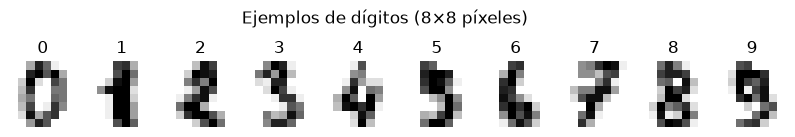

In [2]:
digits = load_digits()
X, y = digits.data, digits.target
print(X.shape)

fig, axes = plt.subplots(1, 10, figsize=(10, 1.4))
for ax, imagen, etiqueta in zip(axes, digits.images, digits.target):
    ax.imshow(imagen, cmap="gray_r")
    ax.set_title(etiqueta)
    ax.axis("off")
fig.suptitle("Ejemplos de dígitos (8×8 píxeles)", y=1.1)
plt.show()

Todos los píxeles comparten unidad y rango (0–16), así que aquí **no** estandarizamos antes de la PCA: la variabilidad de cada píxel es información (los bordes de la imagen casi no varían).

### 3.2. PCA: cuánta varianza conservar

Componentes para el 50% de la varianza: 5
Componentes para el 90% de la varianza: 21
Componentes para el 95% de la varianza: 29


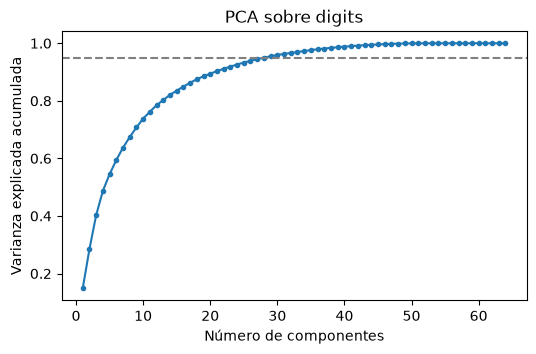

Las 2 primeras componentes explican el 28.5%


In [3]:
pca_completa = PCA().fit(X)
acumulada = np.cumsum(pca_completa.explained_variance_ratio_)

for umbral in [0.5, 0.9, 0.95]:
    print(f"Componentes para el {umbral:.0%} de la varianza: {np.argmax(acumulada >= umbral) + 1}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(np.arange(1, 65), acumulada, marker=".")
ax.axhline(0.95, color="gray", linestyle="--")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza explicada acumulada")
ax.set_title("PCA sobre digits")
plt.show()

print(f"Las 2 primeras componentes explican el {acumulada[1]:.1%}")

Con 2 componentes solo se conserva un 28,5 % de la varianza. Para el 95 % hacen falta 29 de las 64: la mitad de variables, con muy poca pérdida.

¿Cuesta precisión usar esas 29 componentes en lugar de los 64 píxeles? Lo comprobamos con validación cruzada, con la PCA **dentro** del `Pipeline` para que se ajuste solo con cada partición de entrenamiento. `PCA(n_components=0.95)` elige automáticamente las componentes necesarias para el 95 %:

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    "64 píxeles": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "PCA (95 % de varianza)": make_pipeline(PCA(n_components=0.95), LogisticRegression(max_iter=2000)),
    "PCA (2 componentes)": make_pipeline(PCA(n_components=2), LogisticRegression(max_iter=2000)),
    "LDA (2 componentes)": make_pipeline(LinearDiscriminantAnalysis(n_components=2), LogisticRegression(max_iter=2000)),
}
pd.Series({nombre: cross_val_score(m, X, y, cv=cv).mean() for nombre, m in modelos.items()},
          name="exactitud").round(3).to_frame()

,exactitud
64 píxeles,0.971
PCA (95 % de varianza),0.958
PCA (2 componentes),0.601
LDA (2 componentes),0.679


- Con 29 componentes la exactitud baja solo un punto (97,1 % → 95,8 %) con menos de la mitad de variables.
- Con **2** componentes de PCA cae al 60 %: el mapa de 2D pierde demasiada información para clasificar.
- Con 2 componentes de **LDA**, que usa las etiquetas, se llega al 68 %: las 2 direcciones más discriminantes son mejores que las 2 de mayor varianza, pero siguen siendo muy pocas para 10 clases.

### 3.3. PCA, LDA y t-SNE en 2D

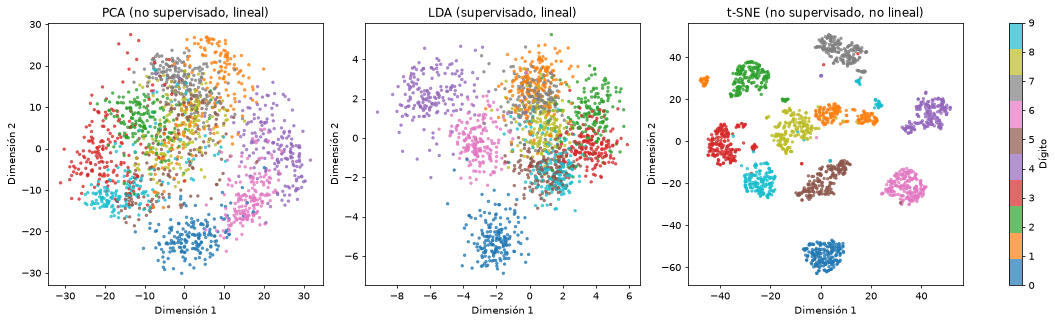

In [5]:
proyecciones = {
    "PCA (no supervisado, lineal)": PCA(n_components=2).fit_transform(X),
    "LDA (supervisado, lineal)": LinearDiscriminantAnalysis(n_components=2).fit_transform(X, y),
    "t-SNE (no supervisado, no lineal)": TSNE(n_components=2, random_state=42).fit_transform(X),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=70, layout="constrained")
for ax, (nombre, Z) in zip(axes, proyecciones.items()):
    puntos = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap="tab10", s=6, alpha=0.7)
    ax.set_title(nombre)
    ax.set_xlabel("Dimensión 1")
    ax.set_ylabel("Dimensión 2")
fig.colorbar(puntos, ax=axes, ticks=range(10), label="Dígito")
plt.show()

- **PCA** muestra algunos dígitos agrupados (el 0 en un extremo) pero con mucho solapamiento: las dos direcciones de máxima varianza no son las que separan los dígitos.
- **LDA** separa mejor varios grupos, porque ha usado las etiquetas para elegir las direcciones. (Aquí se ajusta con todos los datos solo para visualizar; como paso de un modelo, se ajusta con el entrenamiento.)
- **t-SNE** separa casi todos los dígitos en grupos compactos **sin usar las etiquetas**: la estructura de vecindarios en 64 dimensiones es muy clara, aunque ningún plano lineal la capte. Recuerda que las distancias entre grupos y sus tamaños no significan nada.

### 3.4. Componentes de PCA frente a NMF

Como los píxeles son no negativos, podemos aplicar NMF y comparar qué "aprende" cada método. Cada componente se puede dibujar como una imagen de 8×8:

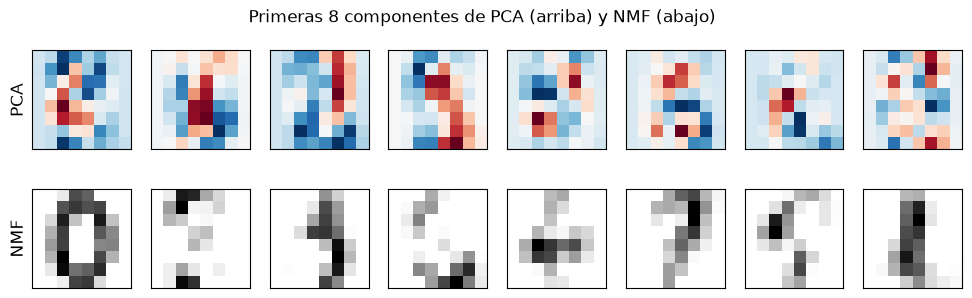

In [6]:
pca8 = PCA(n_components=8).fit(X)
nmf8 = NMF(n_components=8, init="nndsvda", random_state=42, max_iter=500).fit(X)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.3))
for fila, (nombre, componentes, cmap) in enumerate([("PCA", pca8.components_, "RdBu_r"),
                                                     ("NMF", nmf8.components_, "gray_r")]):
    for j, ax in enumerate(axes[fila]):
        ax.imshow(componentes[j].reshape(8, 8), cmap=cmap)
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(nombre, fontsize=12)
fig.suptitle("Primeras 8 componentes de PCA (arriba) y NMF (abajo)")
plt.show()

- Las componentes de **PCA** mezclan zonas positivas (rojo) y negativas (azul) de toda la imagen: son patrones globales de contraste, difíciles de interpretar por separado.
- Las de **NMF** son solo positivas y más localizadas: trazos o "partes" de dígitos (un arco, una barra vertical), y alguna con forma de dígito casi completo (la primera parece un 0). Cada imagen se reconstruye **sumando** unas pocas de estas partes.

`TruncatedSVD` da una descomposición parecida a la PCA sin centrar los datos. Su ventaja real aparece con matrices dispersas, como las de textos, que se verán en los notebooks de NLP:

In [7]:
svd = TruncatedSVD(n_components=29, random_state=42).fit(X)
print(f"TruncatedSVD, varianza explicada con 29 componentes: {svd.explained_variance_ratio_.sum():.3f}")
print(f"PCA,          varianza explicada con 29 componentes: {acumulada[28]:.3f}")

TruncatedSVD, varianza explicada con 29 componentes: 0.955
PCA,          varianza explicada con 29 componentes: 0.955


## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Clase | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `PCA` | `n_components` | Nº de componentes, o fracción de varianza si es un número entre 0 y 1 | `0.95` para modelar; `2` o `3` solo para visualizar |
| | `whiten` | Reescalar las componentes a varianza 1 | Útil antes de modelos sensibles a la escala |
| `TruncatedSVD` | `n_components` | Nº de componentes | Para matrices dispersas; no centra los datos |
| `NMF` | `n_components`, `init` | Nº de partes e inicialización | `init="nndsvda"` converge mejor; solo datos ≥ 0 |
| `LinearDiscriminantAnalysis` | `n_components` | Nº de direcciones discriminantes | Como máximo, nº de clases − 1 |
| `TSNE` | `perplexity` | Nº aproximado de vecinos considerados | Entre 5 y 50; probar varios valores |
| | `init`, `random_state` | Inicialización y semilla | `init="pca"` conserva mejor la estructura global; fija la semilla para reproducir |
| `umap.UMAP` | `n_neighbors`, `min_dist`, `metric` | Escala local/global, compacidad, distancia | `metric="cosine"` para *embeddings* de texto; `"jaccard"` para datos binarios |

### 4.2. Errores comunes

Varios de estos errores salen de trabajar con datos reales: accidentes de tráfico con coordenadas, datos meteorológicos y muchas variables one-hot, y un análisis de recetas representadas con *embeddings* de texto y con ingredientes en formato binario.

**1. No escalar variables con unidades distintas.** La PCA busca la máxima varianza, y la varianza depende de las unidades. En *wine*, la prolina (desviación típica ≈ 315) domina todas las demás variables:

In [8]:
X_wine, y_wine = load_wine(return_X_y=True, as_frame=True)

sin_escalar = PCA(n_components=2).fit(X_wine)
con_escalado = make_pipeline(StandardScaler(), PCA(n_components=2)).fit(X_wine)

print(f"Sin escalar: varianza explicada {sin_escalar.explained_variance_ratio_.round(3)}, "
      f"variable con más peso en la 1.ª componente: {X_wine.columns[np.abs(sin_escalar.components_[0]).argmax()]}")
print(f"Escalando:   varianza explicada {con_escalado[-1].explained_variance_ratio_.round(3)}")

for nombre, pasos in [("sin escalar", [PCA(n_components=2)]),
                      ("escalando", [StandardScaler(), PCA(n_components=2)])]:
    modelo = make_pipeline(*pasos, LogisticRegression(max_iter=2000))
    print(f"Exactitud con 2 componentes, {nombre}: {cross_val_score(modelo, X_wine, y_wine, cv=cv).mean():.3f}")

Sin escalar: varianza explicada [0.998 0.002], variable con más peso en la 1.ª componente: proline
Escalando:   varianza explicada [0.362 0.192]
Exactitud con 2 componentes, sin escalar: 0.697
Exactitud con 2 componentes, escalando: 0.955


Sin escalar, la "primera componente" (99,8 % de la varianza) es en la práctica la prolina sola, y el resto de medidas químicas se pierde. Escalando, las dos componentes resumen información de todas las variables, y la exactitud de un clasificador con esas 2 componentes pasa del 69,7 % al 95,5 % (ver [escalado](../03-preparacion-datos/03-transformacion-datos.ipynb)).

**2. Escalar solo una parte de las variables.** En el análisis de accidentes se estandarizaron las 4 variables numéricas (coordenadas, velocidad media y racha de viento), pero no las 29 columnas one-hot (tipo de vía y día de la semana), que se quedaron en 0/1 con una varianza mucho menor. La primera componente quedó dominada por el viento (racha y velocidad media, con pesos de 0,7 cada una), y el tipo de vía y el día, que eran la mayoría de las columnas, apenas contaban. Mezclar escalas es una **ponderación implícita**: decide sin querer qué variables importan.

**3. No mirar la varianza explicada antes de interpretar un mapa 2D.** En ese mismo análisis, las 2 primeras componentes conservaban solo el **54 %** de la varianza, y hacían falta **10** para llegar al 90 %. Un gráfico de 2 componentes que conserva la mitad de la información dice poco de la otra mitad. Informa siempre de `explained_variance_ratio_` junto al gráfico.

**4. Concluir que la variable objetivo "no se puede predecir" porque no se separa en 2D.** Al proyectar los accidentes con PCA y t-SNE, las clases de gravedad aparecían mezcladas, y de ahí se dedujo que las proyecciones no servían para predecir. Pero PCA y t-SNE **no usan la variable objetivo**: que no la separen en 2 dimensiones no dice nada de lo que un modelo puede aprender con todas las variables. En *digits*, la PCA 2D mezcla bastantes dígitos (60 % de exactitud), mientras que un modelo con los 64 píxeles llega al 97 % (3.2). Para saber si hay señal predictiva, **entrena y valida un modelo**.

**5. Leer un mapa de t-SNE como si fuera un mapa de distancias.** El resultado depende de la perplejidad y de la semilla, y la separación entre grupos y sus tamaños no son interpretables:

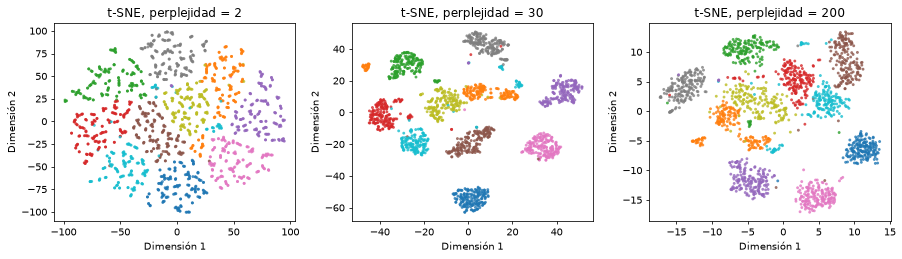

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=70)
for ax, perplejidad in zip(axes, [2, 30, 200]):
    Z = TSNE(n_components=2, perplexity=perplejidad, random_state=42).fit_transform(X)
    ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap="tab10", s=4, alpha=0.7)
    ax.set_title(f"t-SNE, perplejidad = {perplejidad}")
    ax.set_xlabel("Dimensión 1")
    ax.set_ylabel("Dimensión 2")
plt.tight_layout()
plt.show()

Con perplejidad muy baja (2), cada punto solo "mira" a un par de vecinos: los grupos pierden su forma y el mapa se convierte en una nube casi uniforme en la que los dígitos apenas se distinguen. Con 30 aparecen grupos compactos y bien separados. Con 200, los grupos siguen ahí, pero cambian de posición, de forma y de distancia entre sí, y la escala de los ejes pasa de ±100 a ±15. Son los **mismos datos**. Prueba varias perplejidades y quédate con las conclusiones que se mantienen en todas.

**6. Usar t-SNE como paso de un modelo o agrupar sobre la proyección 2D.** `TSNE` solo tiene `fit_transform`: no puede proyectar datos nuevos, así que no sirve dentro de un `Pipeline` de predicción. Y el clustering debe hacerse sobre los **datos originales** (o sobre una PCA con muchas componentes), no sobre el mapa 2D, que deforma distancias y densidades. En el análisis de recetas se hizo bien: UMAP sirvió para visualizar, y el agrupamiento se hizo sobre los *embeddings* originales de 384 dimensiones.

**7. Usar una distancia que no encaja con el tipo de datos.** En ese mismo análisis, el proyector UMAP configurado con distancia coseno para los *embeddings* de texto se reutilizó con la matriz binaria de ingredientes. Para vectores binarios (presencia o ausencia), la **distancia de Jaccard** mide mejor la similitud: cuenta los ingredientes compartidos y no se deja influir por los miles de ingredientes que ninguna de las dos recetas tiene. En t-SNE y UMAP, el parámetro `metric` debe elegirse según los datos.

**8. Ajustar la reducción con todos los datos antes de dividir.** Como cualquier transformación, la PCA se ajusta solo con el entrenamiento (dentro del `Pipeline`, como en 3.2). Con LDA, que usa las etiquetas, ajustarla con todos los datos filtra información del conjunto de prueba y da resultados demasiado optimistas.

## 5. Comparación con métodos relacionados

| Método | Tipo | Usa la objetivo | Datos | `transform` de datos nuevos | Uso principal |
|---|---|---|---|---|---|
| **PCA** | Lineal | No | Numéricos (escalados si tienen unidades distintas) | Sí | Comprimir, quitar colinealidad y ruido, visualización rápida |
| **TruncatedSVD** | Lineal | No | Matrices dispersas (textos) | Sí | Análisis semántico latente (LSA), textos |
| **NMF** | Lineal, no negativa | No | No negativos (píxeles, recuentos) | Sí | Componentes interpretables como "partes" o temas |
| **LDA** | Lineal | **Sí** | Numéricos con clases | Sí | Proyección que separa clases; como máximo K − 1 dimensiones |
| **t-SNE** | No lineal | No | Cualquiera, con una distancia adecuada | **No** | Visualizar estructura local en 2D/3D |
| **UMAP** | No lineal | No (opcionalmente sí) | Cualquiera, con una distancia adecuada | Sí | Visualización y preprocesado para clustering; más rápido que t-SNE |

**Regla práctica:** para **modelar**, empieza por la PCA con la varianza explicada como guía (o LDA si hay clases y pocas dimensiones bastan). Para **explorar**, compara PCA (rápida, fiel a las distancias globales) con t-SNE o UMAP (fieles a los vecindarios), y no saques conclusiones que solo aparecen en uno de ellos.

## 6. Referencias

### Fuentes

- scikit-learn: [*Decomposing signals in components*](https://scikit-learn.org/stable/modules/decomposition.html) (PCA, `TruncatedSVD`, NMF), [*Manifold learning*](https://scikit-learn.org/stable/modules/manifold.html) (t-SNE) y [*Linear and Quadratic Discriminant Analysis*](https://scikit-learn.org/stable/modules/lda_qda.html) (LDA como reducción de dimensionalidad).
- Datasets: [digits y wine en scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html), procedentes de los conjuntos *Optical Recognition of Handwritten Digits* y *Wine* del repositorio UCI.

### Para saber más

- Jolliffe, I. T. y Cadima, J. (2016). *Principal component analysis: a review and recent developments*. Philosophical Transactions of the Royal Society A, 374, 20150202. Revisión de la PCA, de sus fundamentos a sus variantes.
- van der Maaten, L. y Hinton, G. (2008). *Visualizing Data using t-SNE*. Journal of Machine Learning Research, 9, 2579–2605. El artículo original de t-SNE.